# Comparing Dependence Plots

1. Partial Dependence (PDP)
2. Marginal Plots (MP)
3. Individual Conditional Expectation (ICE)
4. Average Local Effect (ALE)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

In [2]:
# Test Data
x1 = np.random.rand(200, 1)
x = np.hstack((x1, x1))
x += np.random.normal(0, 0.05, x.shape)

# Generate labels
y = np.power(x[:, 0], 2) + np.sin(2 * np.pi * x[:, 1]) + np.random.normal(0, 0.1, x.shape[0])

Observations:
1. Introducing correlation between predictors is like intersecting the 3D surface of $(y, x_1, x_2)$.
2. The grid size matters for your estimate, there's a bias-variance tradeoff (just like in kernel smoothing, right?)

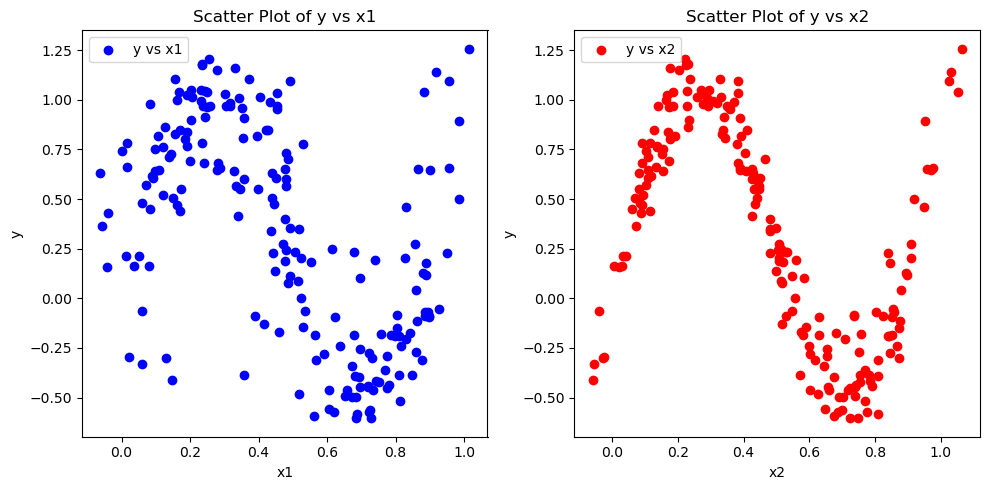

In [3]:
# Visualize the data
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(x[:, 0], y, color='blue', label='y vs x1')
plt.xlabel('x1')
plt.ylabel('y')
plt.title('Scatter Plot of y vs x1')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(x[:, 1], y, color='red', label='y vs x2')
plt.xlabel('x2')
plt.ylabel('y')
plt.title('Scatter Plot of y vs x2')
plt.legend()

plt.tight_layout()
plt.show()

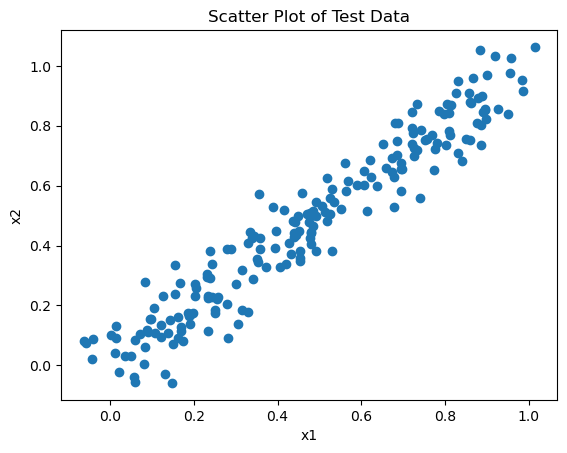

In [4]:
plt.scatter(x[:, 0], x[:, 1])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Scatter Plot of Test Data')
plt.show()

In [5]:
# Fit the model
clf = HistGradientBoostingRegressor(max_iter=100, random_state=42).fit(x, y)

In [6]:
# Partial Dependence
def partial_dependence(x, feature_index, clf, grid_size=100):
    # Create a grid for the specified feature
    grid = np.linspace(np.min(x[:, feature_index]), np.max(x[:, feature_index]), grid_size)
    
    # Calculate partial dependence
    pd_values = []
    for i, grid_value in enumerate(grid[1:]):
        # get all data points with the feature between grid values
        mask = (x[:, feature_index] <= grid_value) & (x[:, feature_index] >= grid[i - 1])
        subset = x[mask]

        if subset.size == 0:
            pd_values.append(np.nan)
        else:
            # Calculate the mean of the other feature
            pass
    
    return grid, np.array(pd_values)

In [7]:
# Visualize the partial dependence for the first feature
feature_index = 0
grid, pd_values = partial_dependence(x, feature_index)

plt.plot(grid, pd_values)
plt.title(f'Partial Dependence for Feature {feature_index}')
plt.xlabel('Feature Value')
plt.ylabel('Partial Dependence')
plt.show()

TypeError: partial_dependence() missing 1 required positional argument: 'clf'